# Master-catalog Results and Validation

This notebook reads the products generated by
`2a_singphotandmatching_compute.ipynb`. It performs no photometry or matching.


## 1. Load Products


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.wcs import FITSFixedWarning, WCS

warnings.filterwarnings("ignore", category=FITSFixedWarning)


def project_root():
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == "Notebooks" else cwd


PROJECT_ROOT = project_root()
COSMOS = 1
DATA_ROOT = PROJECT_ROOT / "COSMOS_data"
BANDS_7DT = [f"m{i}" for i in range(400, 900, 25)]
SINGLE_DIR = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot"
MATCH_DIR = SINGLE_DIR / "matching"
FIG_DIR = MATCH_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def get_image_path(cosmos, band):
    paths = list((DATA_ROOT / f"COSMOS{cosmos}").glob(f"*{band}*.com.fits"))
    if len(paths) != 1:
        raise FileNotFoundError(f"Expected one {band} image, found {len(paths)}")
    return paths[0]


master = Table.read(MATCH_DIR / "master_catalog.fits")
band_uncertainty = Table.read(MATCH_DIR / "band_uncertainty.fits")
matching_diagnostics = Table.read(MATCH_DIR / "matching_diagnostics_7dt.fits")
consistency_diagnostics = Table.read(MATCH_DIR / "consistency_diagnostics_7dt.fits")
finalcat_diagnostics = Table.read(MATCH_DIR / "finalcat_matching_diagnostics.fits")
radius_diagnostics = Table.read(MATCH_DIR / "finalcat_radius_diagnostics.fits")

classes = np.asarray(master["master_class"]).astype(str)
has_7dt = np.asarray(master["has_7dt"], dtype=bool)
has_finalcat = np.asarray(master["has_finalcat"], dtype=bool)
n_bands = np.asarray(master["n_7dt_bands"], dtype=int)

print(f"Master rows: {len(master)}")
print(f"Master columns: {len(master.colnames)}")
for label in ("matched", "7dt_only", "finalcat_only"):
    print(f"{label}: {int((classes == label).sum())}")
print(f"7DT-bearing: {int(has_7dt.sum())}")
print(f"FINALCAT-bearing: {int(has_finalcat.sum())}")
print(f"Strict 20-band: {int((n_bands == 20).sum())}")


Master rows: 75259
Master columns: 237
matched: 2977
7dt_only: 16512
finalcat_only: 55770
7DT-bearing: 19489
FINALCAT-bearing: 58747
Strict 20-band: 1157


## 2. Integrity Checks


In [2]:
assert len(np.unique(np.asarray(master["master_id"], dtype=np.int64))) == len(master)
assert np.isin(classes, ["matched", "7dt_only", "finalcat_only"]).all()
assert int(((classes == "matched") | (classes == "7dt_only")).sum()) == int(has_7dt.sum())
assert int(((classes == "matched") | (classes == "finalcat_only")).sum()) == int(has_finalcat.sum())
assert np.all(np.isfinite(np.asarray(master["master_ra"], dtype=float)))
assert np.all(np.isfinite(np.asarray(master["master_dec"], dtype=float)))

for band in BANDS_7DT:
    sid_mask = np.ma.getmaskarray(master[f"{band}_source_id"])
    mag_mask = np.ma.getmaskarray(master[f"{band}_mag"])
    err_mask = np.ma.getmaskarray(master[f"{band}_mag_err"])
    assert np.array_equal(sid_mask, mag_mask)
    assert np.array_equal(sid_mask, err_mask)

selected_finalcat = np.asarray(finalcat_diagnostics["selected"], dtype=bool)
selected_status = np.asarray(finalcat_diagnostics["match_status"]).astype(str)
pair_match = selected_finalcat & np.isin(selected_status, ["matched_unique", "matched_ambiguous"])
if pair_match.any():
    radius = float(master.meta["RADIUS"])
    assert np.nanmax(np.asarray(finalcat_diagnostics["separation_arcsec"], dtype=float)[pair_match]) <= radius

print("All catalog integrity checks passed.")


All catalog integrity checks passed.


## 3. 7DT Matching Diagnostics


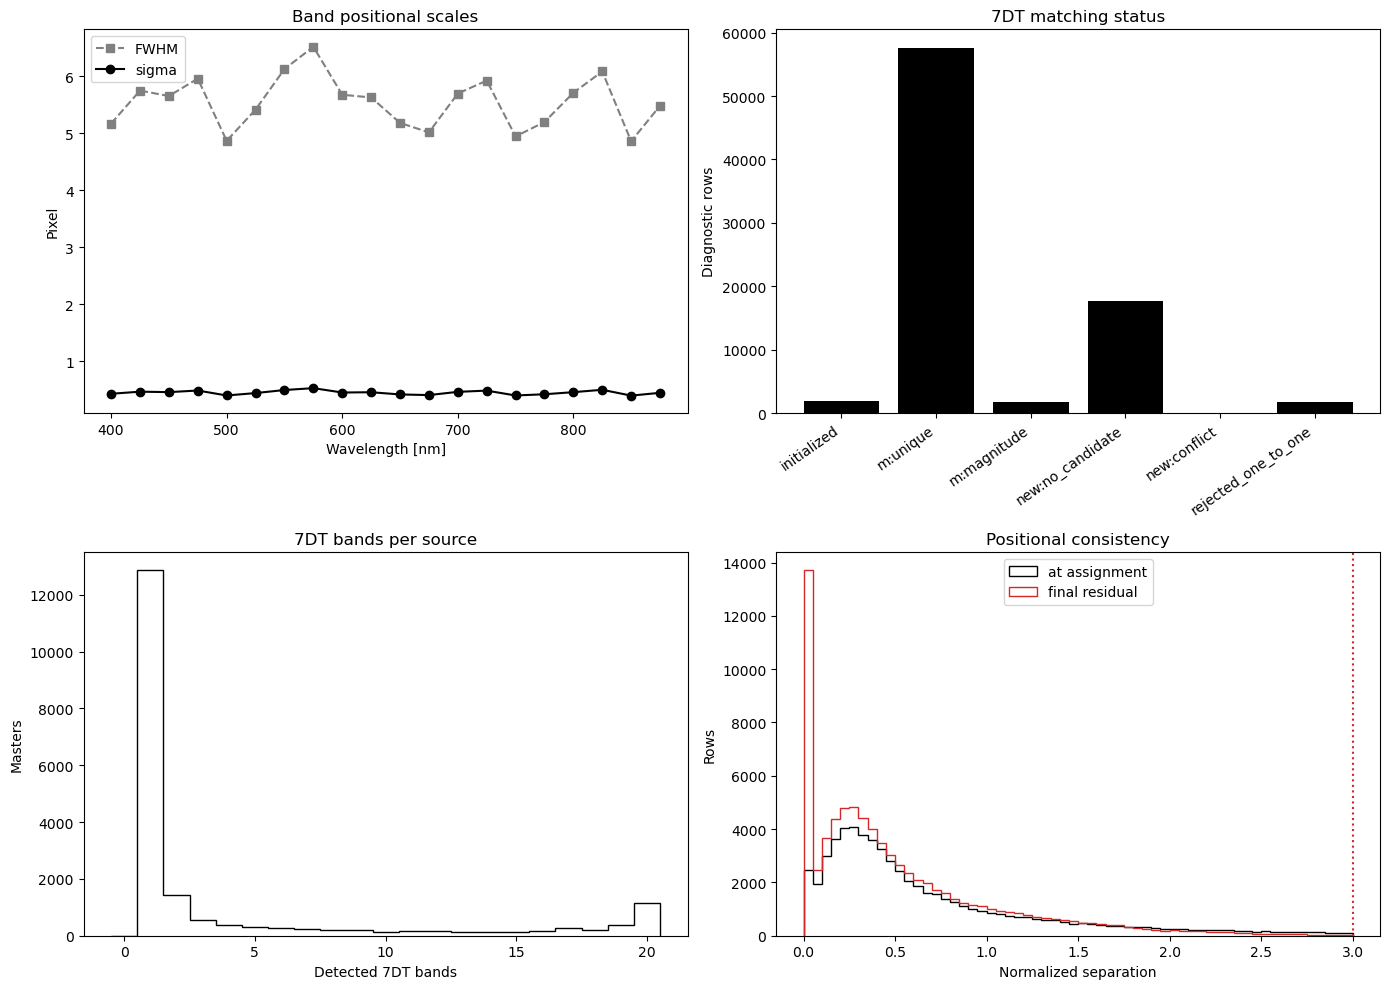

Suspect 7DT members: 117/78882


In [3]:
statuses = np.asarray(matching_diagnostics["match_status"]).astype(str)
status_order = [
    "initialized", "matched_unique", "matched_magnitude", "matched_position_fallback",
    "new_master_no_candidate", "new_master_conflict", "rejected_one_to_one",
]
status_labels = [status for status in status_order if status in set(statuses)]
status_counts = [int((statuses == status).sum()) for status in status_labels]
selected = np.asarray(matching_diagnostics["selected"], dtype=bool)
normalized_sep = np.asarray(matching_diagnostics["normalized_separation"], dtype=float)[selected]
normalized_sep = normalized_sep[np.isfinite(normalized_sep)]
normalized_residual = np.asarray(consistency_diagnostics["normalized_residual"], dtype=float)
normalized_residual = normalized_residual[np.isfinite(normalized_residual)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
wavelength = np.asarray([int(str(band)[1:]) for band in band_uncertainty["band"]])
axes[0, 0].plot(wavelength, band_uncertainty["fwhm_pix"], "s--", color="gray", label="FWHM")
axes[0, 0].plot(wavelength, band_uncertainty["sigma_pix"], "o-", color="black", label="sigma")
axes[0, 0].set(xlabel="Wavelength [nm]", ylabel="Pixel", title="Band positional scales")
axes[0, 0].legend()
axes[0, 1].bar(np.arange(len(status_labels)), status_counts, color="black")
axes[0, 1].set_xticks(np.arange(len(status_labels)), [s.replace("matched_", "m:").replace("new_master_", "new:") for s in status_labels], rotation=35, ha="right")
axes[0, 1].set(ylabel="Diagnostic rows", title="7DT matching status")
axes[1, 0].hist(n_bands[has_7dt], bins=np.arange(22) - 0.5, histtype="step", color="black")
axes[1, 0].set(xlabel="Detected 7DT bands", ylabel="Masters", title="7DT bands per source")
axes[1, 1].hist(normalized_sep, bins=60, range=(0, 3), histtype="step", color="black", label="at assignment")
axes[1, 1].hist(normalized_residual, bins=60, range=(0, 3), histtype="step", color="tab:red", label="final residual")
axes[1, 1].axvline(3, color="tab:red", linestyle=":")
axes[1, 1].set(xlabel="Normalized separation", ylabel="Rows", title="Positional consistency")
axes[1, 1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "7dt_matching_summary.png", dpi=150, bbox_inches="tight")
plt.show()

flags = np.asarray(consistency_diagnostics["consistency_flag"]).astype(str)
print(f"Suspect 7DT members: {int((flags == 'suspect').sum())}/{len(flags)}")


## 4. FINALCAT Radius and Union Diagnostics


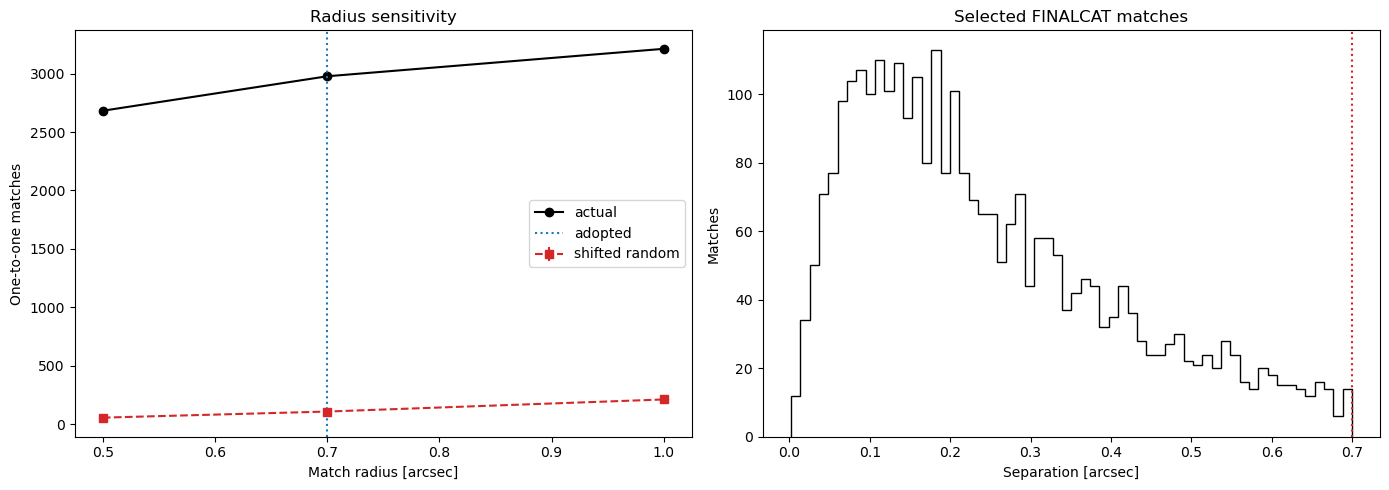

In [4]:
radii = np.unique(np.asarray(radius_diagnostics["radius_arcsec"], dtype=float))
samples = np.asarray(radius_diagnostics["sample"]).astype(str)
actual_matches = []
random_mean = []
random_std = []
for radius in radii:
    at_radius = np.isclose(np.asarray(radius_diagnostics["radius_arcsec"], float), radius)
    actual = np.asarray(radius_diagnostics["n_selected"], int)[at_radius & (samples == "actual")]
    random = np.asarray(radius_diagnostics["n_selected"], int)[at_radius & (samples == "random")]
    actual_matches.append(int(actual[0]))
    random_mean.append(float(np.mean(random)))
    random_std.append(float(np.std(random)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(radii, actual_matches, "o-", color="black", label="actual")
axes[0].errorbar(radii, random_mean, yerr=random_std, fmt="s--", color="tab:red", label="shifted random")
axes[0].axvline(float(master.meta["RADIUS"]), color="tab:blue", linestyle=":", label="adopted")
axes[0].set(xlabel="Match radius [arcsec]", ylabel="One-to-one matches", title="Radius sensitivity")
axes[0].legend()

matched_pair = np.asarray(finalcat_diagnostics["selected"], bool) & np.isin(
    np.asarray(finalcat_diagnostics["match_status"]).astype(str), ["matched_unique", "matched_ambiguous"]
)
separation = np.asarray(finalcat_diagnostics["separation_arcsec"], dtype=float)[matched_pair]
axes[1].hist(separation[np.isfinite(separation)], bins=60, histtype="step", color="black")
axes[1].axvline(float(master.meta["RADIUS"]), color="tab:red", linestyle=":")
axes[1].set(xlabel="Separation [arcsec]", ylabel="Matches", title="Selected FINALCAT matches")
fig.tight_layout()
fig.savefig(FIG_DIR / "finalcat_radius_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Matched, 7DT-only, and FINALCAT-only Populations


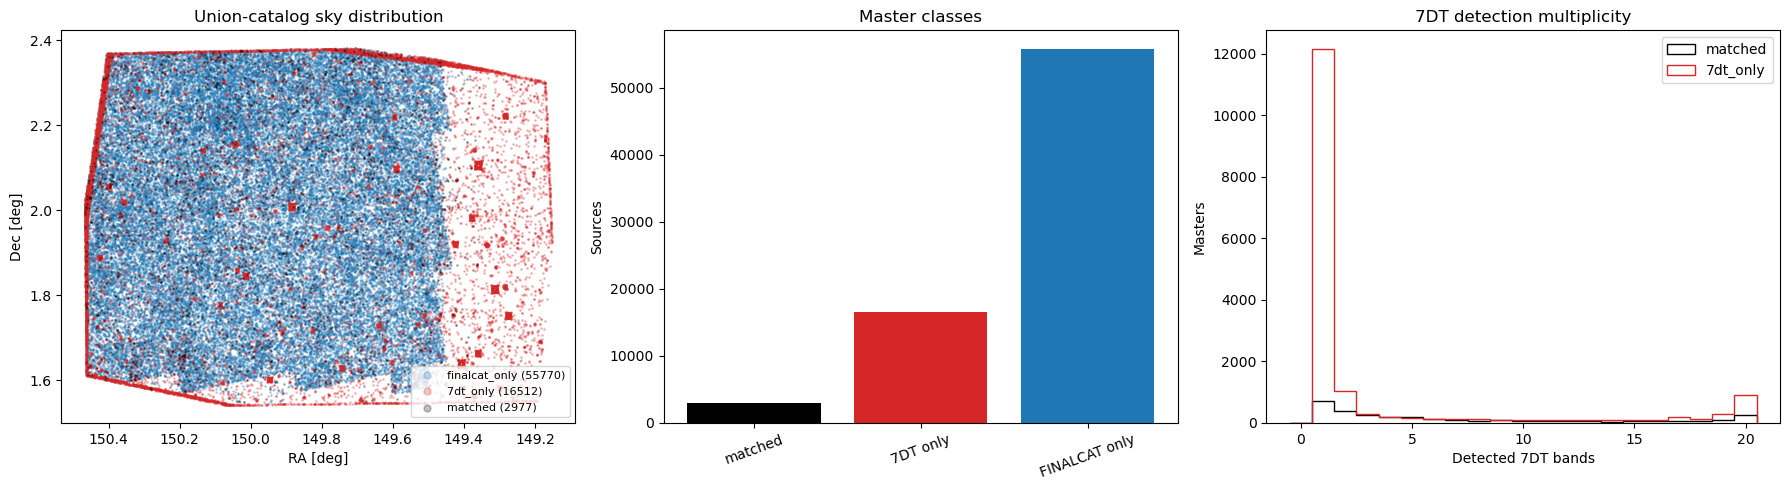

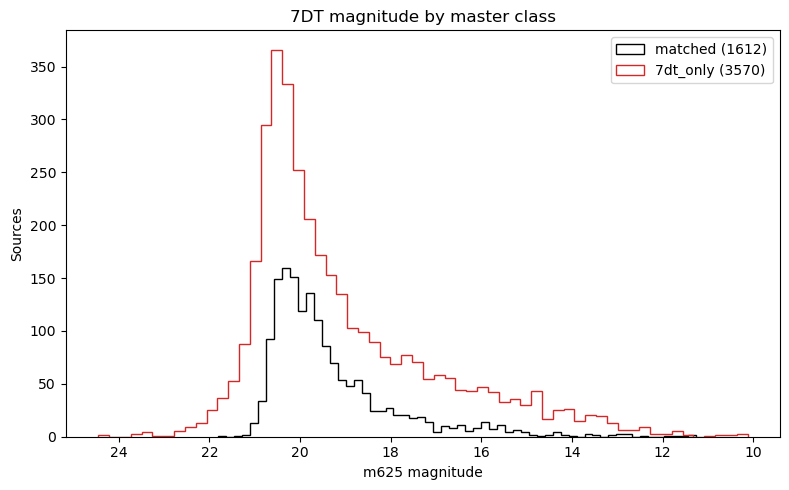

In [5]:
colors = {"matched": "black", "7dt_only": "tab:red", "finalcat_only": "tab:blue"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for label in ("finalcat_only", "7dt_only", "matched"):
    choose = classes == label
    axes[0].scatter(master["master_ra"][choose], master["master_dec"][choose], s=1, alpha=0.25,
                    color=colors[label], label=f"{label} ({choose.sum()})")
axes[0].set(xlabel="RA [deg]", ylabel="Dec [deg]", title="Union-catalog sky distribution")
axes[0].invert_xaxis()
axes[0].legend(markerscale=5, fontsize=8)

axes[1].bar(["matched", "7DT only", "FINALCAT only"],
            [(classes == "matched").sum(), (classes == "7dt_only").sum(), (classes == "finalcat_only").sum()],
            color=[colors["matched"], colors["7dt_only"], colors["finalcat_only"]])
axes[1].set(ylabel="Sources", title="Master classes")
axes[1].tick_params(axis="x", rotation=20)

for label in ("matched", "7dt_only"):
    choose = classes == label
    axes[2].hist(n_bands[choose], bins=np.arange(22) - 0.5, histtype="step",
                 color=colors[label], label=label)
axes[2].set(xlabel="Detected 7DT bands", ylabel="Masters", title="7DT detection multiplicity")
axes[2].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "master_population_summary.png", dpi=150, bbox_inches="tight")
plt.show()

band = "m625"
mag = np.ma.filled(master[f"{band}_mag"], np.nan).astype(float)
fig, ax = plt.subplots(figsize=(8, 5))
for label in ("matched", "7dt_only"):
    values = mag[classes == label]
    values = values[np.isfinite(values)]
    ax.hist(values, bins=60, histtype="step", color=colors[label], label=f"{label} ({len(values)})")
ax.invert_xaxis()
ax.set(xlabel=f"{band} magnitude", ylabel="Sources", title="7DT magnitude by master class")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / f"{band}_magnitude_by_class.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Strict 20-band Catalog and Example SEDs


Saved 1157 strict 20-band sources to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/master_full20_catalog.fits


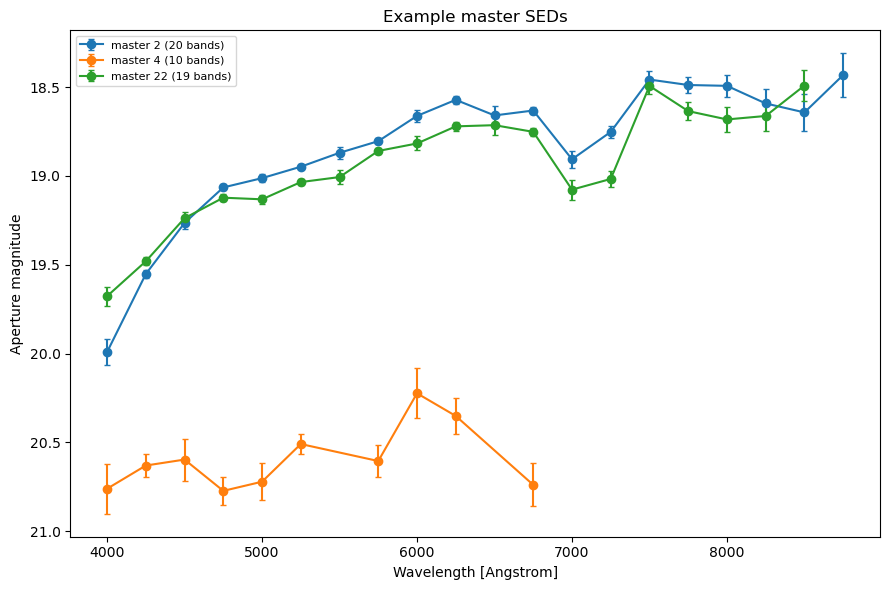

In [6]:
full20 = master[n_bands == 20]
full20_path = MATCH_DIR / "master_full20_catalog.fits"
full20.write(full20_path, overwrite=True)
print(f"Saved {len(full20)} strict 20-band sources to {full20_path}")

wavelength = np.asarray([int(band[1:]) * 10 for band in BANDS_7DT], dtype=float)
candidates = np.flatnonzero((classes == "matched") & (n_bands >= 10))
if len(candidates) < 3:
    candidates = np.flatnonzero(has_7dt & (n_bands >= 10))
candidates = candidates[:3]

fig, ax = plt.subplots(figsize=(9, 6))
for row in candidates:
    mag = np.asarray([np.ma.filled(master[f"{band}_mag"][row], np.nan) for band in BANDS_7DT], dtype=float)
    err = np.asarray([np.ma.filled(master[f"{band}_mag_err"][row], np.nan) for band in BANDS_7DT], dtype=float)
    good = np.isfinite(mag) & np.isfinite(err)
    ax.errorbar(wavelength[good], mag[good], yerr=err[good], marker="o", capsize=2,
                label=f"master {int(master['master_id'][row])} ({n_bands[row]} bands)")
ax.invert_yaxis()
ax.set(xlabel="Wavelength [Angstrom]", ylabel="Aperture magnitude", title="Example master SEDs")
if len(candidates):
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "example_master_seds.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Category Cutouts


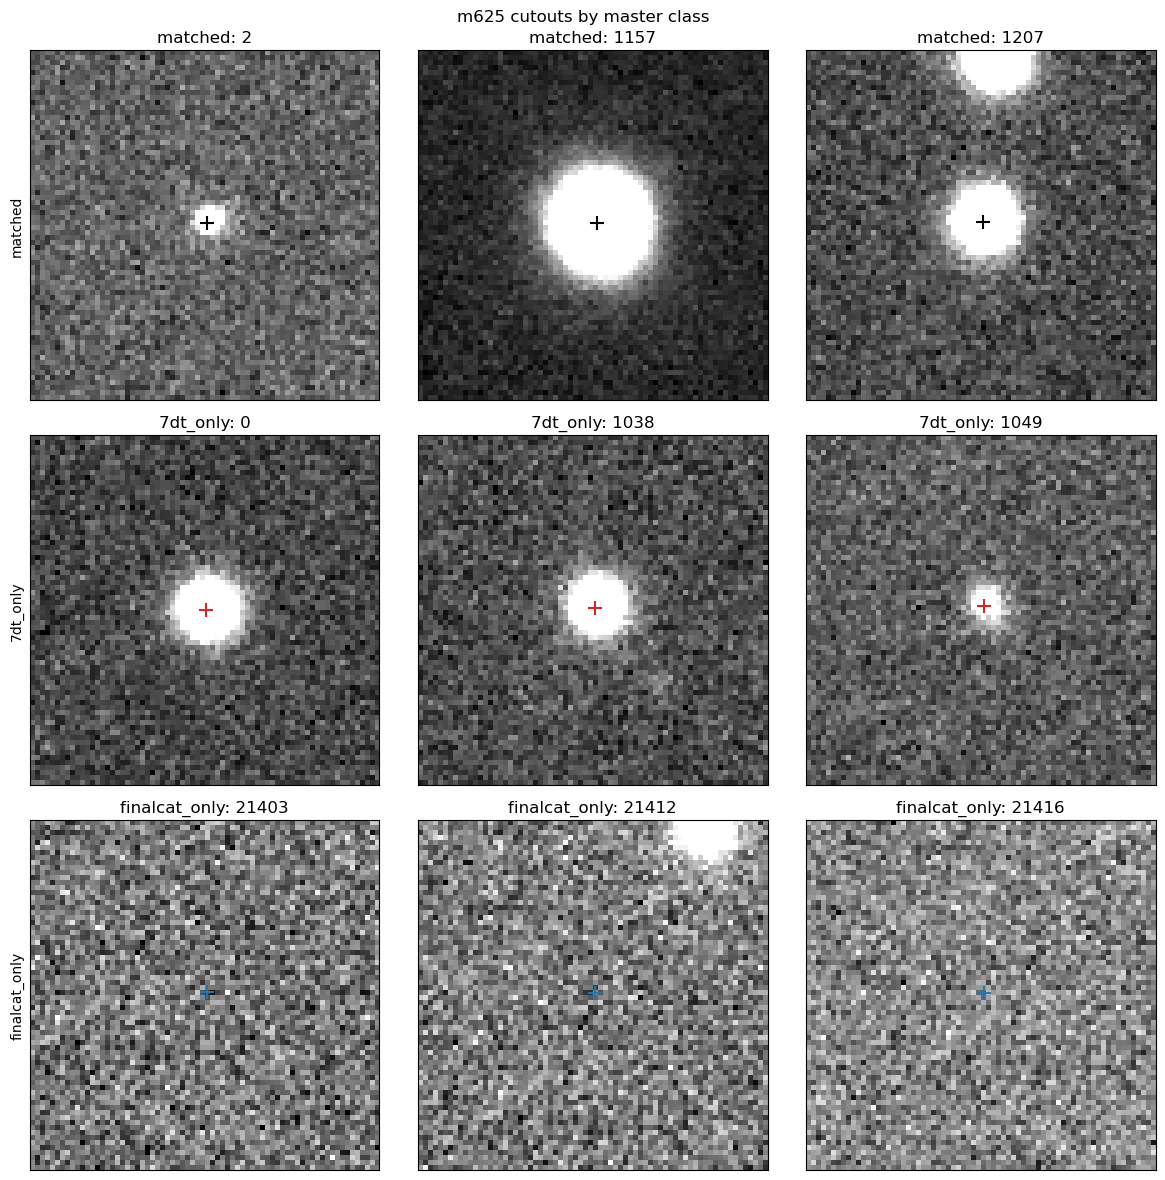

Saved result figures to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures


In [7]:
display_band = "m625"
image_path = get_image_path(COSMOS, display_band)
image = fits.getdata(image_path)
display_wcs = WCS(fits.getheader(image_path))
half = 35

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for row_index, label in enumerate(("matched", "7dt_only", "finalcat_only")):
    population = np.flatnonzero(classes == label)
    if label != "finalcat_only":
        population = population[np.argsort(n_bands[population])[::-1]]
    else:
        center_distance = np.hypot(
            np.asarray(master["master_x"], float)[population] - (image.shape[1] + 1) / 2,
            np.asarray(master["master_y"], float)[population] - (image.shape[0] + 1) / 2,
        )
        population = population[np.argsort(center_distance)]
    for column_index, row in enumerate(population[:3]):
        ax = axes[row_index, column_index]
        x0 = float(master["master_x"][row]) - 1
        y0 = float(master["master_y"][row]) - 1
        xmin, xmax = max(0, int(x0 - half)), min(image.shape[1], int(x0 + half))
        ymin, ymax = max(0, int(y0 - half)), min(image.shape[0], int(y0 + half))
        cutout = image[ymin:ymax, xmin:xmax]
        ax.imshow(cutout, origin="lower", cmap="gray", norm=ImageNormalize(cutout, interval=ZScaleInterval()),
                  extent=[xmin, xmax, ymin, ymax])
        ax.scatter([x0], [y0], marker="+", s=100, color=colors[label])
        ax.set_title(f"{label}: {int(master['master_id'][row])}")
        ax.set_xticks([])
        ax.set_yticks([])
    axes[row_index, 0].set_ylabel(label)

fig.suptitle(f"{display_band} cutouts by master class")
fig.tight_layout()
fig.savefig(FIG_DIR / f"{display_band}_cutouts_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved result figures to {FIG_DIR}")
